# Quanten-Hall-Effekt

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
#import scipy.constants as const
#from scipy.optimize import least_squares
#from scipy.stats import linregress
#import os

## 2.2 Messung der Supraleiter-Sprungtemperatur

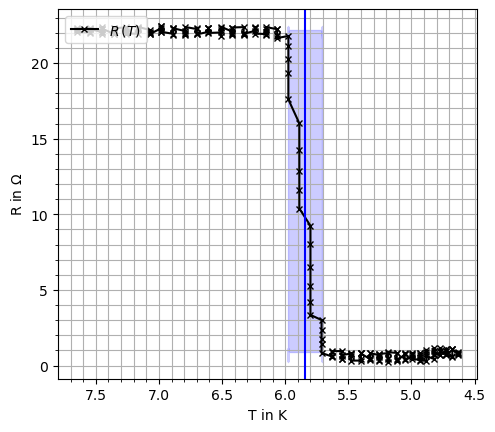

In [2]:
sprungtemp = np.loadtxt('../Messdaten/01122025_QHE/Sprungtemperatur_log.dat', delimiter='\t', usecols=(1,7), skiprows=2450, max_rows=200)
# liest von 2450 bis 2650 ein, da ungefähr bei 2500 der Sprung stattfindet und nimmt die Spalten für Temperatur und Widerstand
T = sprungtemp[:,0]
R = sprungtemp[:,1]


# plotten
fig, (ax1) = plt.subplots(1,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,4.8)) #layout='constrained')
ax1.plot(T, R, 'x-k', ms=4, label=r'$R\,(T)$')
ax1.xaxis.set_inverted(True)
ax1.set_xlabel('T in K')
ax1.set_ylabel(r'R in $\Omega$')
ax1.legend(loc=2)
ax1.grid(which='both')
ax1.minorticks_on()
# farbiger Bereich in dem Bereich fallendes Widerstandes und Linie beim Mittelwert
ax1.fill_betweenx(R,5.975,5.712, alpha= 0.2, color='blue')
ax1.axvline(5.84, color='blue')
plt.show()

22.11918304347826 0.03679975389073723 0.6964130425287356 0.05144236958541855
21.422770000949523 0.08824212347615579


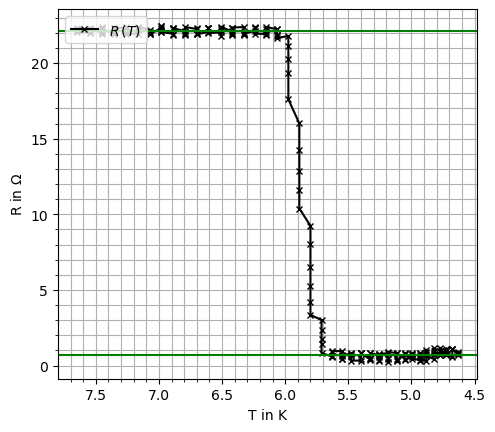

In [7]:
mask_Rhigh = np.where(T>5.975) 
mask_Rlow = np.where(T<5.712) 
Rhigh = np.mean(R[mask_Rhigh])
Rlow = np.mean(R[mask_Rlow])
Rhigh_var = np.var(R[mask_Rhigh])
Rlow_var = np.var(R[mask_Rlow])

print(Rhigh, Rhigh_var, Rlow, Rlow_var)
print(Rhigh-Rlow, Rhigh_var + Rlow_var)

fig, (ax1) = plt.subplots(1,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,4.8)) #layout='constrained')
ax1.plot(T, R, 'x-k', ms=4, label=r'$R\,(T)$')
ax1.xaxis.set_inverted(True)
ax1.set_xlabel('T in K')
ax1.set_ylabel(r'R in $\Omega$')
ax1.legend(loc=2)
ax1.grid(which='both')
ax1.minorticks_on()
# farbiger Bereich in dem Bereich der Standardabweichung, ist aber so klein, dass man es nicht sieht
ax1.fill_between(T,Rhigh - Rhigh_var, Rhigh + Rhigh_var, T > 5.975, alpha = 0.2, color = 'green')
ax1.axhline(Rhigh, color='green')
ax1.fill_between(T,Rlow - Rlow_var, Rlow + Rlow_var, T < 5.712, alpha = 0.2, color = 'green')
ax1.axhline(Rlow, color='green')
plt.show()